<a href="https://colab.research.google.com/github/gunn2006/bank-loan-default-prediction/blob/main/bank_loan_default_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank loan default prediction — simple AI/ML model (Logistic Regression)

This notebook builds a **Logistic Regression** model to predict whether a loan applicant will **default** (fail to repay).

Logistic Regression is used here instead of a more complex model because it is:
- Easy to explain in class — every feature gets **one weight (coefficient)**
- Transparent — you can show the exact formula the model uses to make a decision
- The kind of model real banks actually use for credit-risk scoring, because regulators require lending decisions to be explainable

**Note:** Real bank loan data is private and regulated, so this notebook uses a realistic *synthetic* dataset built with the same features described in a "Data Required" slide for a loan default case study.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 2. Create the synthetic loan applicant dataset

Each row represents one loan applicant. The features are typical of what a bank's credit-risk team would use:
- `annual_income` — applicant's annual income (in thousands)
- `credit_score` — credit bureau score (300–850)
- `loan_amount` — amount requested (in thousands)
- `debt_to_income` — existing monthly debt payments as a % of monthly income
- `employment_years` — years at current job
- `late_payments_2yr` — number of late payments in the last 2 years
- `loan_purpose` — Home, Auto, or Personal

The `default` label (1 = defaulted, 0 = repaid) is generated using simple business rules, so the model has real patterns to learn.

In [2]:
n = 3000

annual_income = np.round(np.random.normal(65, 25, n), 1)
annual_income = np.clip(annual_income, 15, 250)

credit_score = np.round(np.random.normal(680, 80, n)).astype(int)
credit_score = np.clip(credit_score, 300, 850)

loan_amount = np.round(np.random.normal(25, 15, n), 1)
loan_amount = np.clip(loan_amount, 2, 120)

debt_to_income = np.round(np.random.normal(32, 12, n), 1)
debt_to_income = np.clip(debt_to_income, 2, 80)

employment_years = np.round(np.random.exponential(scale=5, size=n), 1)
employment_years = np.clip(employment_years, 0, 35)

late_payments_2yr = np.random.poisson(lam=0.7, size=n)

loan_purpose = np.random.choice(['Home', 'Auto', 'Personal'], size=n, p=[0.3, 0.35, 0.35])

# Simple, explainable business rule for default risk (this is what the model will learn to approximate)
risk_score = (
    -2.6
    - 0.025 * (credit_score - 680) / 10
    - 0.015 * annual_income
    + 0.035 * loan_amount
    + 0.045 * debt_to_income
    - 0.06 * employment_years
    + 0.55 * late_payments_2yr
    + np.where(loan_purpose == 'Personal', 0.25, np.where(loan_purpose == 'Home', -0.15, 0))
    + np.random.normal(0, 0.7, n)
)
default_prob = 1 / (1 + np.exp(-risk_score))
default = (default_prob > 0.5).astype(int)

df = pd.DataFrame({
    'annual_income': annual_income,
    'credit_score': credit_score,
    'loan_amount': loan_amount,
    'debt_to_income': debt_to_income,
    'employment_years': employment_years,
    'late_payments_2yr': late_payments_2yr,
    'loan_purpose': loan_purpose,
    'default': default
})

df.head(10)

,annual_income,credit_score,loan_amount,debt_to_income,employment_years,late_payments_2yr,loan_purpose,default
0,77.4,527,8.3,41.2,2.4,0,Home,0
1,61.5,611,15.5,44.9,4.3,0,Personal,0
2,81.2,647,10.9,38.0,2.9,0,Home,0
3,103.1,831,16.8,8.7,0.1,0,Personal,0
4,59.1,725,21.8,30.1,25.6,1,Personal,0
5,59.1,573,37.6,18.1,3.9,0,Auto,0
6,104.5,719,20.2,29.6,3.2,0,Personal,0
7,84.2,556,2.0,43.8,15.5,0,Personal,0
8,53.3,767,42.1,35.7,0.8,1,Home,0
9,78.6,642,12.4,45.8,1.0,1,Personal,0


## 3. Quick look at the data

In [3]:
print("Dataset shape:", df.shape)
print()
print("Default rate:", round(df['default'].mean() * 100, 1), "%")
print()
df.describe()

Dataset shape: (3000, 8)

Default rate: 18.5 %



,annual_income,credit_score,loan_amount,debt_to_income,employment_years,late_payments_2yr,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000
mean,65.982133,676.474000,25.486533,31.785567,5.063067,0.73800,0.184667
std,24.228612,79.545575,14.524800,11.691211,4.907009,0.88069,0.388092
min,15.000000,426.000000,2.000000,2.000000,0.000000,0.00000,0.000000
25%,49.300000,623.000000,14.500000,23.900000,1.600000,0.00000,0.000000
50%,65.600000,678.000000,24.800000,31.700000,3.700000,1.00000,0.000000
75%,81.825000,731.000000,35.525000,39.600000,7.000000,1.00000,0.000000
max,163.200000,850.000000,77.900000,72.500000,35.000000,5.00000,1.000000


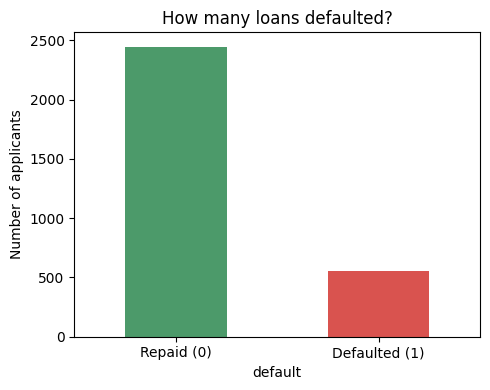

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
df['default'].value_counts().sort_index().plot(kind='bar', color=['#4C9A6A', '#D9534F'], ax=ax)
ax.set_xticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)
ax.set_title('How many loans defaulted?')
ax.set_ylabel('Number of applicants')
plt.tight_layout()
plt.show()

## 4. Prepare the data for the model

- Convert `loan_purpose` (text) into numbers the model can use (one-hot encoding)
- Split into training data (80%) and test data (20%)
- Scale the numbers so no single feature dominates just because it has bigger numbers

In [5]:
df_model = pd.get_dummies(df, columns=['loan_purpose'], drop_first=True)

X = df_model.drop('default', axis=1)
y = df_model['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Features used:", list(X.columns))

Training rows: 2400
Test rows: 600
Features used: ['annual_income', 'credit_score', 'loan_amount', 'debt_to_income', 'employment_years', 'late_payments_2yr', 'loan_purpose_Home', 'loan_purpose_Personal']


## 5. Train the model

This is the actual AI/ML step. Logistic Regression finds one weight per feature that best separates applicants who defaulted from those who repaid.

In [6]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


## 6. Evaluate the model — how good are its predictions?

In [7]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 1), "%")
print()
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))

Accuracy: 91.2 %

              precision    recall  f1-score   support

      Repaid       0.93      0.96      0.95       489
   Defaulted       0.81      0.68      0.74       111

    accuracy                           0.91       600
   macro avg       0.87      0.82      0.84       600
weighted avg       0.91      0.91      0.91       600



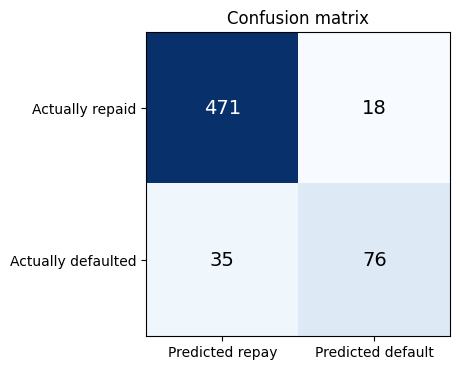

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicted repay', 'Predicted default'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actually repaid', 'Actually defaulted'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

## 7. Why this feature matters — the model's weights

This is the easiest part to present in class. Each feature has **one coefficient**. A positive weight pushes an applicant toward default; a negative weight pushes them toward repayment — and the size of the number shows how strong that effect is.

              feature    weight
       debt_to_income  1.468180
    late_payments_2yr  1.347455
          loan_amount  1.296275
        annual_income -0.964843
     employment_years -0.819999
         credit_score -0.594201
loan_purpose_Personal  0.359622
    loan_purpose_Home -0.191055


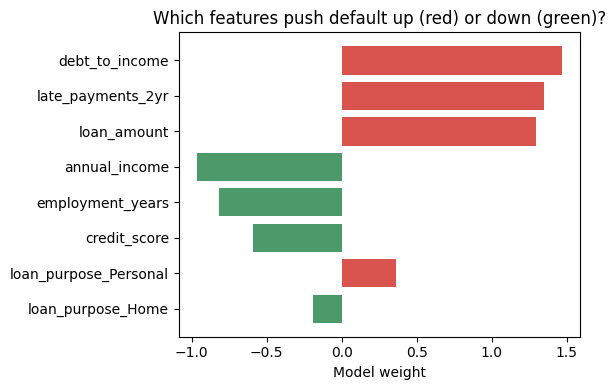

In [9]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'weight': model.coef_[0]
}).sort_values('weight', key=abs, ascending=False)

print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#D9534F' if w > 0 else '#4C9A6A' for w in coef_df['weight']]
ax.barh(coef_df['feature'], coef_df['weight'], color=colors)
ax.set_title('Which features push default up (red) or down (green)?')
ax.set_xlabel('Model weight')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Try it live — predict default risk for one applicant

Change the numbers below to describe any applicant and run the cell to see the model's prediction. This is a good moment to demo in class.

In [10]:
def predict_default(annual_income, credit_score, loan_amount, debt_to_income,
                     employment_years, late_payments_2yr, loan_purpose='Auto'):
    row = pd.DataFrame([{
        'annual_income': annual_income,
        'credit_score': credit_score,
        'loan_amount': loan_amount,
        'debt_to_income': debt_to_income,
        'employment_years': employment_years,
        'late_payments_2yr': late_payments_2yr,
        'loan_purpose_Home': 1 if loan_purpose == 'Home' else 0,
        'loan_purpose_Personal': 1 if loan_purpose == 'Personal' else 0,
    }])
    row = row[X.columns]
    row_scaled = scaler.transform(row)
    prob = model.predict_proba(row_scaled)[0][1]
    print(f"Predicted default probability: {prob * 100:.1f}%")
    print("Prediction:", "LIKELY TO DEFAULT" if prob > 0.5 else "LIKELY TO REPAY")
    return prob

# Example: a risky applicant — low income, low credit score, high debt-to-income, late payments
predict_default(annual_income=28, credit_score=560, loan_amount=40, debt_to_income=55,
                 employment_years=1, late_payments_2yr=3, loan_purpose='Personal')

Predicted default probability: 100.0%
Prediction: LIKELY TO DEFAULT


np.float64(0.9997762525721442)

In [11]:
# Example: a strong applicant — high income, good credit, stable job, no late payments
predict_default(annual_income=95, credit_score=780, loan_amount=15, debt_to_income=18,
                 employment_years=10, late_payments_2yr=0, loan_purpose='Home')

Predicted default probability: 0.0%
Prediction: LIKELY TO REPAY


np.float64(4.190146211445869e-05)

## Summary for the case study

- **Model type:** Logistic Regression (Classification)
- **Why this model:** it is easy to explain — every input feature has one clear weight, and banks need explainable models to justify lending decisions to regulators and customers
- **Top default drivers found by the model:** low credit score and a history of late payments increase default risk; higher income, longer job tenure, and lower debt-to-income reduce it
- **Business action:** applicants flagged as high-risk can be routed for manual underwriting review, offered a smaller loan amount, or given a higher interest rate to offset risk
- **Caveat:** trained on synthetic data built for this classroom exercise — a real deployment would use the bank's actual applicant and repayment data under strict fair-lending and privacy regulations, and would need bias testing across protected groups before going live